In [1]:
pip install qiskit qiskit-aer matplotlib numpy

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.6 MB 7.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.6 MB 8.1 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.6 MB 7.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 7.8 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 7.8 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 7.8 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 4.8 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 4.3 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.



CONTROLLED-NOT CIRCUIT
     ┌───┐┌───┐     ┌─┐   
q_0: ┤ X ├┤ H ├──■──┤M├───
     └───┘└───┘┌─┴─┐└╥┘┌─┐
q_1: ──────────┤ X ├─╫─┤M├
               └───┘ ║ └╥┘
c: 2/════════════════╩══╩═
                     0  1 

MEASUREMENT RESULTS
00 count : 596
P(00)   : 0.4967
01 count : 0
P(01)   : 0.0000
10 count : 0
P(10)   : 0.0000
11 count : 604
P(11)   : 0.5033


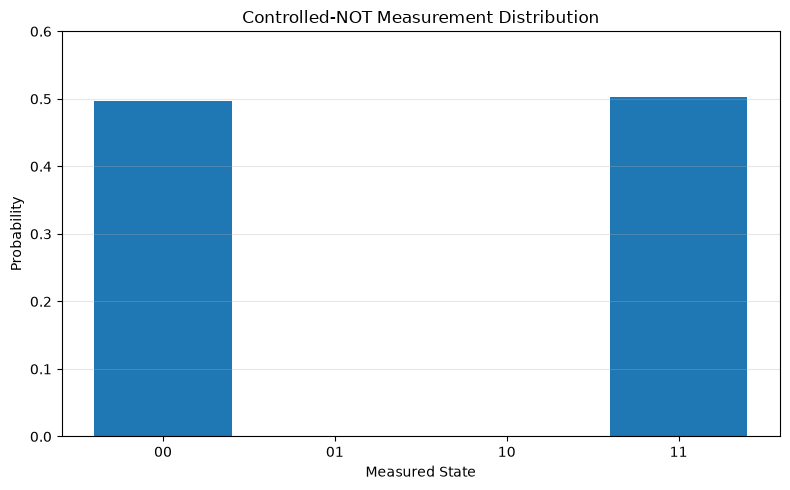

In [3]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

shots = 1200

qc = QuantumCircuit(2, 2)
qc.x(0)
qc.h(0)
qc.cx(0, 1)
qc.measure(0, 0)
qc.measure(1, 1)

print("\nCONTROLLED-NOT CIRCUIT")
print("=" * 55)
print(qc.draw())

simulator = AerSimulator()
result = simulator.run(qc, shots=shots).result()
counts = result.get_counts()

print("\nMEASUREMENT RESULTS")
print("=" * 55)

for state in ["00", "01", "10", "11"]:
    count = counts.get(state, 0)
    probability = count / shots
    print(f"{state} count : {count}")
    print(f"P({state})   : {probability:.4f}")

states = ["00", "01", "10", "11"]
probabilities = [counts.get(state, 0) / shots for state in states]

plt.figure(figsize=(8, 5))
plt.bar(states, probabilities)
plt.xlabel("Measured State")
plt.ylabel("Probability")
plt.title("Controlled-NOT Measurement Distribution")
plt.ylim(0, 0.6)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()